# 챗봇 시스템을 구현하기 위한 text generator 모델 사용
## 사내에서 자체 모델을 구현하기에 어려움이 있는걸 대비하여 기존 모델(Llama-3)에 RAG기법을 사용하여 모델 테스트
- Fine-tuning: 기존 모델을 직접 학습하여 새로운 데이터 패턴을 반영하는 방식
  - Llama-3 모델을 LoRA 또는 PEFT 방식으로 미세 조정
  - 데이터셋을 생성하여 모델을 직접 재학습
- RAG: 기존 모델은 그대로 사용하면서 검색 기능을 추가하는 방식
  - 벡터 데이터베이스(FAISS)를 활용해 실시간 검색
  - 검색된 문서를 Llama-3의 입력 프롬프트에 포함하여 응답 생성
### 위의 두가지 방식 중 필요로 하는 방식으로 적용

## 목차
1. 파이프라인을 활용한 text-generator 모델 사용
2. AutoModelForCausalLm을 활용한 RAG + text-generator 모델 새용
3. 챗봇 형식으로 구현
4. 결론

### 1-1. 기존 모델을 사용하기 위한 pipeline 을 통한 모델 확인 (Colab)

In [3]:
# !pip install torch transformers==4.40.0 accelerate
# !pip install sentence-transformers faiss-cpu numpy

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


  Using cached tokenizers-0.21.0-cp39-abi3-macosx_11_0_arm64.whl.metadata (6.7 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 53.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 57.9 MB/s eta 0:00:00
Using cached tokenizers-0.21.0-cp39-abi3-macosx_11_0_arm64.whl (2.6 MB)
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.19.1
    Uninstalling tokenizers-0.19.1:
      Successfully uninstalled tokenizers-0.19.1
  Attempting uninstall: transformers
    Found existing installation: transformers 4.40.0
    Uninstalling transformers-4.40.0:
      Successfully uninstalled transformers-4.40.0


In [2]:
# 기본 모델을 사용하는 코드
import transformers
import torch

model_id = "MLP-KTLim/llama-3-Korean-Bllossom-8B"

pipeline = transformers.pipeline(
    "text-generation",
    model=model_id,
    model_kwargs={"torch_dtype": torch.bfloat16},
    device_map="auto",
)

pipeline.model.eval()

PROMPT = '''You are a helpful AI assistant. Please answer the user's questions kindly. 당신은 유능한 AI 어시스턴트 입니다. 사용자의 질문에 대해 친절하게 답변해주세요.'''
instruction = "서울의 유명한 관광 코스를 만들어줄래?"

messages = [
    {"role": "system", "content": f"{PROMPT}"},
    {"role": "user", "content": f"{instruction}"}
    ]

prompt = pipeline.tokenizer.apply_chat_template(
        messages, 
        tokenize=False, 
        add_generation_prompt=True
)

terminators = [
    pipeline.tokenizer.eos_token_id,
    pipeline.tokenizer.convert_tokens_to_ids("<|eot_id|>")
]

outputs = pipeline(
    prompt,
    max_new_tokens=2048,
    eos_token_id=terminators,
    do_sample=True,
    temperature=0.6,
    top_p=0.9
)

print(outputs[0]["generated_text"][len(prompt):])



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/opt/homebrew/anaconda3/envs/llm/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/opt/homebrew/anaconda3/envs/llm/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/opt/homebrew/anaconda3/envs/llm/lib/python3.9/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/opt/homebrew/anaconda3/envs/llm/lib/python3.9/site-packages/traitlets/config/application.py", line 1075, in launc

config.json:   0%|          | 0.00/710 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

model-00001-of-00004.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

model-00002-of-00004.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/51.1k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/444 [00:00<?, ?B/s]

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


NotImplementedError: The operator 'aten::isin.Tensor_Tensor_out' is not currently implemented for the MPS device. If you want this op to be added in priority during the prototype phase of this feature, please comment on https://github.com/pytorch/pytorch/issues/77764. As a temporary fix, you can set the environment variable `PYTORCH_ENABLE_MPS_FALLBACK=1` to use the CPU as a fallback for this op. WARNING: this will be slower than running natively on MPS.

# 벡터 데이터 베이스를 이용한 RAG 기능 사용 후 텍스트 생성

In [ ]:
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np

# 문서 임베딩 모델 (KoSimCSE 등 한글용 모델 사용 가능)
embed_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

# 문서 데이터 준비
documents = [
    "김규산은 리턴플러스에 재직중인 개발자 입니다.",
    "리턴플러스는 사원의 개발인력이 80% 이상 존재하고 있습니다.",
    "리턴플러스는 STO 사업의 선두주자로서 한조각 프로젝트를 진행하고 있습니다.",
    "리턴플러스 회사의 대표자 이름은 최정만 입니다."
    "리턴플러스는 IT솔루션과 인프라를 구축하고 디지털 컨버전스를 연구하며 프롭테크와 블록체인 기반의 핀테크 기술을 통한 디지털 자산 및 실물 자산 유동화 플랫폼 서비스를 제공합니다 "
    "리턴플러스 :: 블록체인 디지털 금융 자산 유동화 플랫폼 서비스 기업"
]

# 문서를 벡터로 변환
doc_embeddings = embed_model.encode(documents)

# FAISS 벡터 데이터베이스 생성 및 저장
dimension = doc_embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)  # L2 거리 기반 인덱스 생성
index.add(np.array(doc_embeddings, dtype=np.float32))  # 문서 추가

# FAISS 인덱스 저장
faiss.write_index(index, "document_index.faiss")
np.save("documents.npy", documents)


In [ ]:
def retrieve_documents(query, top_k=2):
    """사용자의 질문(query)과 가장 유사한 문서를 검색하는 함수"""
    query_embedding = embed_model.encode([query])
    D, I = index.search(np.array(query_embedding, dtype=np.float32), top_k)  # top_k 개수만큼 검색 (상위 n개 검색)
    return [documents[i] for i in I[0]]

# 예제 실행
query = "리턴플러스는 무슨 회사야?"
retrieved_docs = retrieve_documents(query)
print("🔍 검색된 문서:", retrieved_docs)

In [ ]:
# 검색된 문서를 입력 프롬프트에 포함
import transformers
import torch

model_id = "MLP-KTLim/llama-3-Korean-Bllossom-8B"

# Llama-3 파이프라인 설정
pipeline = transformers.pipeline(
    "text-generation",
    model=model_id,
    model_kwargs={"torch_dtype": torch.bfloat16},
    device_map="auto",
)

pipeline.model.eval()

PROMPT = '''You are a helpful AI assistant. Please answer the user's questions kindly.'''

# 사용자의 질문
instruction = "리턴플러스는 무슨 회사야?"

# RAG 검색을 통해 문서 가져오기
retrieved_docs = retrieve_documents(instruction)

# LLM 입력 프롬프트 생성 (RAG 문서 포함)
messages = [
    {"role": "system", "content": f"{PROMPT}"},
    {"role": "system", "content": f"Here is additional information to help answer: {retrieved_docs}"},
    {"role": "user", "content": f"{instruction}"}
]

prompt = pipeline.tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

# Llama-3 응답 생성
outputs = pipeline(
    prompt,
    max_new_tokens=2048,
    do_sample=True,
    temperature=0.6,
    top_p=0.9
)

print(outputs[0]["generated_text"][len(prompt):])


### 2-1. 기존 모델 세분화 조정을 위한 직접 모델 사용

In [ ]:
# 기존 모델을 사용하는 코드 (cuda환경)
import os
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

model_id = 'MLP-KTLim/llama-3-Korean-Bllossom-8B'

tokenizer = AutoTokenizer.from_pretrained(model_id)

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,  # VRAM 절약 (float16 사용 가능)
    device_map="auto",  # GPU + CPU 자동 분배
    offload_folder="offload"  # VRAM 부족 시 일부 가중치를 CPU로 오프로드
)

model.eval()

PROMPT = '''You are a helpful AI assistant. Please answer the user's questions kindly. 당신은 유능한 AI 어시스턴트 입니다. 사용자의 질문에 대해 친절하게 답변해주세요.'''

instruction = "리턴플러스는 무슨 회사야?"

messages = [
        {"role": "system", "content": f"{PROMPT}"},
        {"role": "system", "content": f"Here is additional information to help answer: {retrieved_docs}"},
        {"role": "user", "content": f"{instruction}"}
    ]

# apply_chat_template: 메시지를 모델이 이해할 수 있는 형태로 변환
input_ids = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt"
    ).to(model.device)

# 종료 토큰 설정
terminators = [
    tokenizer.eos_token_id,
    tokenizer.convert_tokens_to_ids("<|eot_id|>")
]

# 모델 응답 생성
outputs = model.generate(
    input_ids,
    max_new_tokens=2048,
    eos_token_id=terminators,
    do_sample=True,
    temperature=0.6,
    top_p=0.9
)

print(tokenizer.decode(outputs[0][input_ids.shape[-1]:], skip_special_tokens=True))



# 3. 챗봇 형태로 대화 구현

In [ ]:
# 기존 모델을 활용하여 챗봇형태로 구현하는 부분

# import os
# import torch
# from transformers import AutoTokenizer, AutoModelForCausalLM

# model_id = 'MLP-KTLim/llama-3-Korean-Bllossom-8B'

# tokenizer = AutoTokenizer.from_pretrained(model_id)

# model = AutoModelForCausalLM.from_pretrained(
#     model_id,
#     torch_dtype=torch.bfloat16,  # VRAM 절약 (float16 사용 가능)
#     device_map="auto",  # GPU + CPU 자동 분배
#     offload_folder="offload"  # VRAM 부족 시 일부 가중치를 CPU로 오프로드
# )

# model.eval()

PROMPT = '''You are a helpful AI assistant. Please answer the user's questions kindly. 당신은 유능한 AI 어시스턴트 입니다. 사용자의 질문에 대해 친절하게 답변해주세요.'''

# 대화 히스토리 초기화
messages = [
    {"role": "system", "content": f"{PROMPT}"},
    {"role": "system", "content": f"Here is additional information to help answer: {retrieved_docs}"},
]

# 챗봇 루프 실행
while True:
    # 사용자 입력 받기
    instruction = input("질문을 입력하세요 (종료: exit): ")
    if instruction.lower() == "exit":
        break

    # 대화기록에 새로운 질문 추가
    messages.append({"role": "user", "content": f"{instruction}"})

    # 입력 데이터 변환 
    # apply_chat_template: 메시지를 모델이 이해할 수 있는 형태로 변환
    input_ids = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True, # 자동으로 프롬프트 형식을 추가하는 역할
        return_tensors="pt" # 데이터를 pytorch의 텐서로 변환하는 역할
    ).to(model.device)

    # 종료 토큰 설정
    terminators = [
        tokenizer.eos_token_id, # 기본적인 문장 토큰
        tokenizer.convert_tokens_to_ids("<|eot_id|>") # 모델이 특정 토큰을 만나면 생성 준비하도록 설정
    ]

    # 모델 응답 생성
    outputs = model.generate(
        input_ids, 
        max_new_tokens=2048,
        eos_token_id=terminators, # 모델이 응답 생성을 종료하는 기준 (terminators 의 종료 토큰을 만나면 문장을 끊는다는 의미)
        do_sample=True, # 확률적 샘플링 적용 (자연스럽고 창의적인 응답)
        temperature=0.6, # 랜덤성 조절
        top_p=0.9 # 상위 n% 내에서 선택
    )

    # 모델 응답 저장
    response = tokenizer.decode(outputs[0][input_ids.shape[-1]:], skip_special_tokens=True)

    # 대화 히스토리에 AI 응답 추가
    messages.append({"role": "assistant", "content": response})

    # AI 응답 출력
    print(f"AI 응답: {response}")

### 결론
1. RAG 기법을 활용할 때 시간 절약을 위해서 문장단위의 임베딩 모델을 사용했음에도 불구하고 내가 입력한 문장에 대해서 높은 답변을 나타내는 것으로 확인했습니다. 하지만 실제 운영시에는 다양한 케이스의 문장이 들어올 수 있기 때문에 더욱 세분화된 검색을 위해 단어단위의 임베딩 모델을 사용하는 것도 고려할 필요가 있습니다.

---
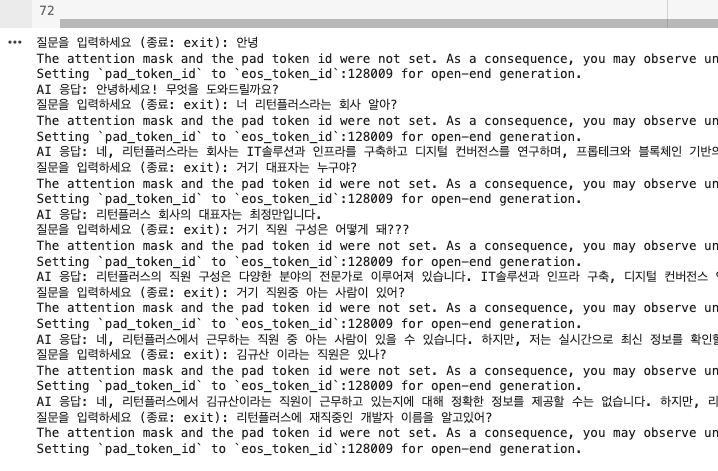

--- 
2. Llama-3-8B 의 한국어 모델을 사용하였으며 단순 프로젝트 용으로는 어느 정도의 답변을 진행하고 있습니다.
LLM 평가지표료는 Auto Metrics / Human Evalution / 다운스트림 태스크 평가(응용 성능 테스트) 세가지 지표가 있는데 현재 인간 평가만 진행 했을 때 단순 사내 설명 정도는 가능할 것으로 판단됩니다.

---
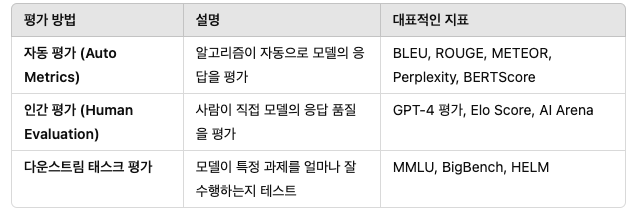

---
3. 최종적으로 모델 성능을 높이기 위해서는 (임베딩모델변경, Llama3 보다 높은 훈련 모델 변경) 두 가지에 대해서는 서비스 사용을 위한 모델 변경으로 판단할 수 있고, 자체 모델을 사용하기 위해서는 텍스트 데이터를 가지고 실제 모델을 구축하는 방식이 있습니다.
